# Analiza dialogowa scenariusza: kto mówi, ile i czyim głosem

## Wersja studencka — moduł 2: GŁOS I PŁEĆ

W poprzednim module zbudowałeś *sieć współwystąpień* — pokazała, kto z kim **pojawia się** w scenach. Ale scenariusz wie znacznie więcej: wie, **kto mówi**, **ile mówi** i **czyimi ustami** prowadzona jest narracja. Ten notatnik wydobywa z tego samego scenariusza warstwę **dialogów**.

Efektem końcowym będzie:
1. odzyskanie czystego tekstu scenariusza (jak w module sieciowym),
2. wydzielenie scen i przypisanie do nich kwestii dialogowych,
3. tabela: która postać wypowiada które kwestie i ile słów,
4. otagowanie postaci płcią,
5. wykres udziału w dialogu z podziałem na płeć,
6. zapis plików `dialogi.csv` i `postacie.csv` do dalszej analizy emocji.

Tak jak poprzednio: nie piszesz kodu samodzielnie. Każdy krok to prompt, który przekazujesz modelowi AI, a wygenerowany kod wklejasz do pustej komórki pod spodem.

## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru (najlepiej ten sam film, co w module sieciowym).
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

Każdy krok prosi model o konkretną nazwę zmiennej dla wyniku (np. `tekst_scenariusza`, `dialogi`, `ranking`). Od tych nazw zależy działanie bramek kontrolnych w notatniku — szczegóły w komórce *Anatomia promptu* poniżej.

**O komórkach `moj_prompt = …`:** dwie takie komórki pojawią się w tym notatniku (Krok 2C i Etap 5). To ćwiczenia z samodzielną decyzją: edytuj zmienną, uruchom (komórka sprawdzi i wypisze gotowy prompt), skopiuj wynik do asystenta AI. W NB2 i NB3 ten wzorzec będzie normą.

## Anatomia promptu — jak czytać instrukcje w tym notatniku

Każdy krok zawiera gotowy prompt do przekazania modelowi AI. Zanim go użyjesz, przeczytaj go uważnie — wszystkie prompty mają ten sam szkielet **7 sekcji**:

| Sekcja | Co zawiera | Dlaczego ważna |
|---|---|---|
| **Kontekst** | Sytuacja, z której startuje model | Model nie widzi historii Twoich komórek — musi wiedzieć, skąd pochodzi kod i dane |
| **Wejście** | Co dokładnie przekazujesz | Określa, co model ma „zobaczyć" |
| **Zadanie** | Precyzyjna lista czynności | Serce promptu — im konkretniej, tym lepszy kod |
| **Pokaż wynik** | Jak powinna wyglądać odpowiedź | Kontrolujesz kształt wyjścia |
| **Warunek poprawności** | Jak odróżnić dobry wynik od błędnego | Twoja lista kontrolna po uruchomieniu |
| **Jeśli wystąpi błąd** | Co zrobić, gdy coś pójdzie nie tak | Plan B wbudowany w prompt |
| **Nie rób jeszcze** | Co ma poczekać na następny krok | Zapobiega „wybieganiu" modelu do przodu |

> **Twoje zadanie w tym module:** naucz się **czytać** te prompty i rozumieć, dlaczego każda sekcja jest tam, gdzie jest. W NB2 będziesz je **uzupełniać** w komórce kodu `moj_prompt`, a w NB3 — **pisać od zera** w pustym szkielecie. Za każdym razem komórka sprawdzi, czy prompt jest gotowy do skopiowania.

> **O nazwach zmiennych:** każdy prompt prosi model o konkretną nazwę zmiennej (np. `tekst_scenariusza`). To nieprzypadkowe — precyzja w sekcji „Zadanie" to cecha dobrego promptu, a od tych nazw zależy działanie bramek w notatniku.

## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie. Wybierz adres strony scenariusza z IMSDb — najlepiej ten sam film, dla którego budowałeś sieć w module pierwszym.

In [1]:
adres_scenariusza = "https://imsdb.com/scripts/Pulp-Fiction.html"

---
## Etap 1/6 — Odzyskanie czystego tekstu scenariusza

Zaczynamy od tego samego punktu, co moduł sieciowy: pobieramy stronę i wydobywamy z niej sam tekst scenariusza.

In [2]:
# === ETAP 1/6 · ODZYSKANIE TEKSTU SCENARIUSZA ===
assert 'adres_scenariusza' in dir() and adres_scenariusza.startswith("http"), \
    "⛔ Ustaw adres_scenariusza w komórce parametru powyżej."
print(f"📍 Etap 1/6 · Odzyskanie tekstu scenariusza z:\n    {adres_scenariusza}")

📍 Etap 1/6 · Odzyskanie tekstu scenariusza z:
    https://imsdb.com/scripts/Pulp-Fiction.html


### Krok 1A. Pobranie strony i wydobycie tekstu scenariusza

#### Cel i sens analityczny

Cała dalsza analiza opiera się na czystym tekście scenariusza. Musimy odzyskać go z podanego adresu — bez menu, stopek i elementów witryny.

#### Prompt dla modelu

```text
Kontekst:
Pracujesz na stronie scenariusza filmowego z serwisu IMSDb. Strona zawiera menu, linki i elementy witryny, których nie chcemy.

Wejście:
Adres scenariusza zapisany w zmiennej `adres_scenariusza`.

Zadanie:
Pobierz stronę i wydobądź z niej wyłącznie właściwy tekst scenariusza (dialogi i didaskalia), odrzucając nawigację, nagłówki i stopki witryny. Zachowaj oczyszczony tekst w zmiennej o nazwie `tekst_scenariusza`.

Pokaż wynik:
- komunikat, czy pobranie i oczyszczenie się udało,
- liczbę znaków i linii oczyszczonego tekstu,
- pierwsze 15 niepustych linii.

Warunek poprawności:
Podgląd powinien przypominać zapis scenariusza (nagłówki scen, nazwy postaci, kwestie), a nie elementy strony. Tekst nie może być pusty.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem dotyczy adresu, połączenia, czy nieznalezienia bloku z tekstem.

Nie rób jeszcze:
Nie wykrywaj scen ani postaci, nie analizuj dialogów.
```

In [3]:
import requests
from bs4 import BeautifulSoup

try:
    response = requests.get(adres_scenariusza)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'html.parser')

    # IMSDb stores the script content within <td class="scrtext">
    script_block = soup.find('td', class_='scrtext')

    if script_block:
        tekst_scenariusza = script_block.get_text()

        # Output results
        lines = [line.strip() for line in tekst_scenariusza.split('\n') if line.strip()]
        print("✅ Pobranie i oczyszczenie tekstu zakończone sukcesem.")
        print(f"Liczba znaków: {len(tekst_scenariusza):,}")
        print(f"Liczba niepustych linii: {len(lines):,}")
        print("\n--- Pierwsze 15 niepustych linii ---")
        for line in lines[:15]:
            print(line)
    else:
        print("❌ Błąd: Nie znaleziono bloku z tekstem scenariusza na stronie. Sprawdź strukturę HTML.")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas pobierania: {e}")

✅ Pobranie i oczyszczenie tekstu zakończone sukcesem.
Liczba znaków: 304,709
Liczba niepustych linii: 5,558

--- Pierwsze 15 niepustych linii ---
"PULP FICTION" -- by Quentin Tarantino & Roger Avary
"PULP FICTION"
By
Quentin Tarantino & Roger Avary
PULP [pulp] n.
1. A soft, moist, shapeless mass or matter.
2. A magazine or book containing lurid subject matter and
being characteristically printed on rough, unfinished paper.
American Heritage Dictionary: New College Edition
INT. COFFEE SHOP � MORNING
A normal Denny's, Spires-like coffee shop in Los Angeles.
It's about 9:00 in the morning. While the place isn't jammed,
there's a healthy number of people drinking coffee, munching
on bacon and eating eggs.
Two of these people are a YOUNG MAN and a YOUNG WOMAN. The


#### Po uruchomieniu powinieneś zobaczyć

- Potwierdzenie, że tekst został pobrany i oczyszczony.
- Liczbę znaków i linii oraz kilkanaście pierwszych linii wyglądających jak scenariusz.
- Brak widocznego menu, stopki i innych elementów witryny.

---
## Etap 2/6 — Od tekstu do kwestii dialogowych

Zamieniamy ciągły tekst w **tabelę kwestii** — kto, w której scenie, co powiedział. To będzie surowiec do liczenia mowy i emocji.

In [ ]:
# === ETAP 2/6 · OD TEKSTU DO KWESTII DIALOGOWYCH ===
assert 'tekst_scenariusza' in dir() and isinstance(tekst_scenariusza, str) and len(tekst_scenariusza) > 100, \
    "⛔ Najpierw uruchom Etap 1 — brak zmiennej `tekst_scenariusza`."
print(f"📍 Etap 2/6 · Wykrywanie scen i kwestii. "
      f"Wejście: `tekst_scenariusza` ({len(tekst_scenariusza):,} znaków).")

### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Chcemy przypisać każdą kwestię do sceny, w której pada — to pozwoli śledzić emocje w czasie. Najpierw odnajdujemy granice scen.

#### Prompt dla modelu

```text
Kontekst:
W scenariuszach nowe sceny otwierają nagłówki opisujące miejsce i czas akcji, często zaczynające się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza w zmiennej `tekst_scenariusza`.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami i nagłówkami. Zachowaj wynik w zmiennej o nazwie `sceny`, tak aby w kolejnym kroku dało się przypisać każdą kwestię do numeru sceny.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu, a nie jak dialog.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że nagłówki są niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj kwestii do scen ani postaci.
```

In [4]:
import re

# Patterns usually starting headers in screenplays
scene_header_patterns = [
    r'^INT\..*',
    r'^EXT\..*',
    r'^I/E\..*',
    r'^INT\s.*',
    r'^EXT\s.*'
]

sceny = []
current_scene_num = 1

# Split text into lines to find headers
lines = tekst_scenariusza.split('\n')

for line in lines:
    stripped_line = line.strip()
    # Check if line matches any scene header pattern (case insensitive)
    if any(re.match(pattern, stripped_line, re.IGNORECASE) for pattern in scene_header_patterns):
        sceny.append({
            'numer_sceny': current_scene_num,
            'naglowek': stripped_line
        })
        current_scene_num += 1

# Output results
print(f"✅ Łączna liczba rozpoznanych scen: {len(sceny)}")
print("\n--- Pierwszych 8 rekordów (numer | nagłówek) ---")
for s in sceny[:8]:
    print(f"{s['numer_sceny']} | {s['naglowek']}")

✅ Łączna liczba rozpoznanych scen: 94

--- Pierwszych 8 rekordów (numer | nagłówek) ---
1 | INT. COFFEE SHOP � MORNING
2 | INT. '74 CHEVY (MOVING) � MORNING
3 | INT. CHEVY (TRUNK) � MORNING
4 | EXT. APARTMENT BUILDING COURTYARD � MORNING
5 | INT. RECEPTION AREA (APARTMENT BUILDING) � MORNING
6 | INT. ELEVATOR � MORNING
7 | INT. APARTMENT BUILDING HALLWAY � MORNING
8 | INT. APARTMENT (ROOM 49) � MORNING


#### Po uruchomieniu powinieneś zobaczyć

- Liczbę scen rozpoznanych w całym tekście.
- Listę pierwszych nagłówków scen.

### Krok 2B. Wydobycie kwestii dialogowych

#### Cel i sens analityczny

W zapisie scenariusza kwestia dialogowa ma stały wzór: **nazwa postaci** (wielkimi literami, wcięta), a pod nią **tekst wypowiedzi**. Wydobędziemy te pary i przypiszemy je do scen.

#### Prompt dla modelu

```text
Kontekst:
W scenariuszu kwestia dialogowa wygląda tak: w osobnej linii nazwa postaci zapisana wielkimi literami i wcięta, a bezpośrednio pod nią jedna lub kilka linii wypowiedzi. Nazwa może mieć dopisek w nawiasie (wskazówka aktorska), który należy usunąć. Linie pisane od lewego marginesu to zwykle didaskalia.

Wejście:
Tekst scenariusza w `tekst_scenariusza` i lista scen w `sceny`.

Zadanie:
Przejdź przez tekst i wydobądź wszystkie kwestie dialogowe. Dla każdej kwestii zapisz: numer sceny, oczyszczoną nazwę postaci, treść wypowiedzi i liczbę słów. Nazwy postaci oczyść (wielkie litery, bez dopisków w nawiasach). Pomiń didaskalia, nagłówki scen i przejścia montażowe. Zachowaj wynik jako tabelę o nazwie `dialogi`.

Pokaż wynik:
- łączną liczbę wydobytych kwestii,
- liczbę unikalnych postaci mówiących,
- próbkę 15 wierszy: `numer sceny | postać | liczba słów | początek kwestii`.

Warunek poprawności:
W kolumnie postaci powinny dominować imiona lub nazwy, a treść kwestii powinna wyglądać jak wypowiedź — nie jak opis kamery.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych fragmentów i wyjaśnij przyczynę.

Nie rób jeszcze:
Nie licz sumarycznej mowy postaci ani nie analizuj płci.
```

In [5]:
import pandas as pd
import re

dialogi_list = []
current_scene_idx = -1
lines = tekst_scenariusza.split('\n')

# Helper to detect if a line is a character name
# Usually centered/indented (more than 10 spaces) and uppercase
def is_character_line(line):
    stripped = line.strip()
    if not stripped or not stripped.isupper():
        return False
    # Ignore technical directions like CUT TO:
    if stripped.endswith(':') or any(x in stripped for x in ['FADE', 'CUT', 'TITLE']):
        return False
    # Check indentation - IMSDb scripts usually have ~20+ spaces for characters
    leading_spaces = len(line) - len(line.lstrip())
    return leading_spaces >= 15

i = 0
while i < len(lines):
    line = lines[i]
    stripped = line.strip()

    # Check if we entered a new scene
    if any(re.match(p, stripped, re.IGNORECASE) for p in scene_header_patterns):
        current_scene_idx += 1

    # Check for character name
    elif current_scene_idx >= 0 and is_character_line(line):
        # Clean character name (remove parentheticals like (V.O.))
        character = re.sub(r'\(.*\)', '', stripped).strip()

        # Collect dialogue lines below the character name
        dialogue_lines = []
        i += 1
        while i < len(lines):
            next_line = lines[i]
            next_stripped = next_line.strip()

            # Stop if we hit an empty line, a new scene, or another character
            if not next_stripped:
                # However, if next line is also empty, we might be done with the block
                if i + 1 < len(lines) and not lines[i+1].strip():
                    break
                i += 1
                continue

            if is_character_line(next_line) or any(re.match(p, next_stripped, re.IGNORECASE) for p in scene_header_patterns):
                i -= 1 # Step back to process this as a header/character
                break

            # It's likely dialogue text if it has some indentation but less than character
            dialogue_lines.append(next_stripped)
            i += 1

        if dialogue_lines:
            full_text = " ".join(dialogue_lines)
            word_count = len(full_text.split())
            dialogi_list.append({
                'numer_sceny': sceny[current_scene_idx]['numer_sceny'],
                'postac': character,
                'tresc': full_text,
                'liczba_slow': word_count
            })
    i += 1

dialogi = pd.DataFrame(dialogi_list)

print(f"✅ Łączna liczba wydobytych kwestii: {len(dialogi):,}")
print(f"Liczba unikalnych postaci mówiących: {dialogi['postac'].nunique()}")
print("\n--- Próbka 15 wierszy (scena | postać | słowa | tekst) ---")
if not dialogi.empty:
    print(dialogi[['numer_sceny', 'postac', 'liczba_slow', 'tresc']].head(15).to_string(index=False, max_colwidth=50))

✅ Łączna liczba wydobytych kwestii: 1,216
Liczba unikalnych postaci mówiących: 72

--- Próbka 15 wierszy (scena | postać | słowa | tekst) ---
 numer_sceny      postac  liczba_slow                                              tresc
           1   YOUNG MAN           11 No, forget it, it's too risky. I'm through doin...
           1 YOUNG WOMAN           15 You always say that, the same thing every time:...
           1   YOUNG MAN           13 I know that's what I always say. I'm always rig...
           1 YOUNG WOMAN           12        � but you forget about it in a day or two -
           1   YOUNG MAN           19 � yeah, well, the days of me forgittin' are ove...
           1 YOUNG WOMAN           12 When you go on like this, you know what you sou...
           1   YOUNG MAN           12 I sound like a sensible fucking man, is what I ...
           1 YOUNG WOMAN           15 You sound like a duck. (imitates a duck) Quack,...
           1   YOUNG MAN           34 Well take heart, 'c

#### Po uruchomieniu powinieneś zobaczyć

- Łączną liczbę kwestii i liczbę unikalnych postaci mówiących.
- Próbkę wierszy: scena, postać, liczba słów, początek wypowiedzi.
- Wypowiedzi wyglądające jak dialog — bez didaskaliów i nagłówków.

### Krok 2C. Przegląd i oczyszczenie listy postaci

#### Cel i sens analityczny

Parsery scenariuszowe często mylą wskazówki montażowe z dialogami: "FADE TO BLACK", "CONTINUED", "INTERCUT WITH" mogą trafić do tabeli `dialogi` jako nazwy postaci. Jeśli to nastąpi, fałszywe wpisy zawyżą liczbę unikalnych postaci i zepsują rankingi i wykres płci.

Ten krok to punkt kontroli jakości — uruchom komórkę poniżej, przejrzyj listę i usuń fałszywe postacie, jeśli się pojawiły.

> **Ten krok jest opcjonalny.** Jeśli lista wygląda poprawnie (same imiona i nazwy postaci), możesz go pominąć.

In [6]:
# PRZEGLĄD — uruchom i sprawdź listę unikalnych wpisów w kolumnie postaci
assert 'dialogi' in dir(), "⛔ Najpierw uruchom Krok 2B — brak tabeli `dialogi`."
print(f"📋 `dialogi`: {len(dialogi):,} kwestii | kolumny: {list(dialogi.columns)}\n")
# Heurystycznie znajdź kolumnę z nazwami postaci
_kol = next(
    (c for c in dialogi.columns
     if any(k in c.lower() for k in
            ('postac', 'postać', 'character', 'speaker', 'char', 'person'))),
    None
)
if _kol is None:
    _str_cols = [c for c in dialogi.columns if str(dialogi[c].dtype) == 'object']
    _kol = max(_str_cols, key=lambda c: dialogi[c].nunique()) if _str_cols else dialogi.columns[1]
    print(f"⚠️  Nie znaleziono kolumny 'postać' po nazwie — próbuję '{_kol}'.\n")
# Przykładowe wiersze — żeby zobaczyć jak wyglądają dane
print("── Przykładowe wiersze (pierwsze 15) ──────────────────────────")
print(dialogi.head(15).to_string(index=False))
# Unikalne nazwy postaci pod spodem
print(f"\n── Unikalne nazwy postaci w kolumnie '{_kol}' ({dialogi[_kol].nunique()} unikalnych) ──")
print(dialogi[_kol].value_counts().to_string())

📋 `dialogi`: 1,216 kwestii | kolumny: ['numer_sceny', 'postac', 'tresc', 'liczba_slow']

── Przykładowe wiersze (pierwsze 15) ──────────────────────────
 numer_sceny      postac                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            tresc  liczba_slow
           1   YOUNG MAN                                                                                                                                                                                                                                                                

#### Twoja kolej: sprawdź i dostosuj prompt

Przejrzyj listę powyżej. Jeśli widzisz fałszywe postacie (stage directions, przejścia montażowe, adnotacje techniczne) — wpisz je w lukę `[WPISZ: …]` w komórce kodu poniżej i uruchom.

> **Jeśli lista wygląda poprawnie**, wpisz w lukę: `(brak)` — prompt poinformuje model, że nic nie trzeba usuwać, a `dialogi` zostanie bez zmian.

In [11]:
# TWOJA KOLEJ: wpisz fałszywe postacie znalezione w Twoim filmie, potem uruchom.
moj_prompt_oczyszczanie = """
Kontekst:
Masz tabelę kwestii dialogowych `dialogi`. Podczas wydobywania kwestii parser mógł
omyłkowo sklasyfikować wskazówki montażowe lub didaskalia jako nazwy postaci.

Wejście:
Tabela `dialogi` (kolumny widoczne po uruchomieniu komórki przeglądu powyżej).

Zadanie:
Oczyść tabelę. Usuń wiersze, w których kolumna postaci zawiera wpis z poniższej
listy typowych fałszywych postaci:
"FADE TO BLACK", "FADE TO", "FADE IN", "FADE OUT", "CUT TO", "CUT TO BLACK",
"SMASH CUT TO", "DISSOLVE TO", "CONTINUED", "CONTINUES",
"INTERCUT WITH", "BACK TO SCENE", "INSERT", "OMITTED", "TITLE CARD", "SUPER"

Dodatkowo usuń wpisy specyficzne dla mojego filmu:
[WPISZ: np. "FLASHBACK", "ANGLE ON" — lub wpisz: (brak) jeśli nie ma nic do usunięcia]

Jeśli żaden wpis nie wymaga usunięcia — wypisz potwierdzenie i nie modyfikuj tabeli.
Zachowaj wynik (po oczyszczeniu lub bez zmian) jako zmienną `dialogi`.

Pokaż wynik:
- ile wierszy usunięto (0 to poprawny wynik),
- jakie nazwy były w usuniętych wierszach,
- nową łączną liczbę kwestii i unikalnych postaci.

Warunek poprawności:
Lista postaci nie powinna zawierać słów typowych dla notacji filmowej.
Jeżeli "V.O." lub "O.S." pojawia się jako samodzielny wpis (bez imienia przed), też należy do usunięcia.

Jeżeli wystąpi błąd:
Wyjaśnij, której kolumny nie udało się znaleźć w `dialogi`.

Nie rób jeszcze:
Nie przeliczaj sumarycznej mowy ani nie rysuj wykresów.
"""
assert "LIVING ROOM, BATHROOM" not in moj_prompt_oczyszczanie, \
    "⛔ Wypełnij lukę [WPISZ: …] — wypisz fałszywe postacie lub (brak) jeśli lista jest czysta."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt_oczyszczanie)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii dialogowych `dialogi`. Podczas wydobywania kwestii parser mógł
omyłkowo sklasyfikować wskazówki montażowe lub didaskalia jako nazwy postaci.

Wejście:
Tabela `dialogi` (kolumny widoczne po uruchomieniu komórki przeglądu powyżej).

Zadanie:
Oczyść tabelę. Usuń wiersze, w których kolumna postaci zawiera wpis z poniższej
listy typowych fałszywych postaci:
"FADE TO BLACK", "FADE TO", "FADE IN", "FADE OUT", "CUT TO", "CUT TO BLACK",
"SMASH CUT TO", "DISSOLVE TO", "CONTINUED", "CONTINUES",
"INTERCUT WITH", "BACK TO SCENE", "INSERT", "OMITTED", "TITLE CARD", "SUPER"

Dodatkowo usuń wpisy specyficzne dla mojego filmu:
[WPISZ: np. "FLASHBACK", "ANGLE ON" — lub wpisz: (brak) jeśli nie ma nic do usunięcia]

Jeśli żaden wpis nie wymaga usunięcia — wypisz potwierdzenie i nie modyfikuj tabeli.
Zachowaj wynik (po oczyszczeniu lub bez zmian) jako zmienną `dialogi`.

Pokaż wynik:
- ile wierszy usunięto (0 to popraw

In [21]:
import pandas as pd

# List of technical terms to remove
false_characters = [
    "FADE TO BLACK", "FADE TO", "FADE IN", "FADE OUT", "CUT TO", "CUT TO BLACK",
    "SMASH CUT TO", "DISSOLVE TO", "CONTINUED", "CONTINUES",
    "INTERCUT WITH", "BACK TO SCENE", "INSERT", "OMITTED", "TITLE CARD", "SUPER",
    "V.O.", "O.S.", "LIVING ROOM", "TWO SHOT � BUTCH AND MARSELLUS", "BATHROOM", "CLOSEUP � JODY",
    "CLOSEUP � VINCENT", "CLOSEUP � MIA", "CLOSEUP � THE NEEDLE", "CLOSEUP � BLOOD",
    "CLOSEUP � VINCENT'S THUMB", "CLOSEUP � NOTE", "THROUGH THE WINDSHIELD", "MOTEL ROOM � MORNING",
    "THE GOLD WATCH", "COOLIDGE", "MOTEL ROOM", "TWO SHOT � JULES AND VINCENT", "BANG! BANG! BOOM! POW! BAM BAM BAM BAM BAM!",
    "KABOOM!!!!", "NINE MINUTES AND THIRTY-SEVEN SECONDS LATER", "COFFEE SHOP"
]

# Film-specific exclusions (if provided)
film_specific = ["LIVING ROOM, BATHROOM"]
all_to_remove = false_characters + film_specific

# Count before cleaning
count_before = len(dialogi)

# Find rows to remove
mask = dialogi['postac'].isin(all_to_remove)
removed_names = dialogi[mask]['postac'].unique().tolist()

# Clean the dataframe
dialogi = dialogi[~mask].reset_index(drop=True)

# Output results
removed_count = count_before - len(dialogi)
if removed_count > 0:
    print(f"✅ Oczyszczanie zakończone.")
    print(f"Liczba usuniętych wierszy: {removed_count}")
    print(f"Usunięte nazwy: {', '.join(removed_names) if removed_names else 'Brak'}")
    print(f"Nowa łączna liczba kwestii: {len(dialogi):,}")
    print(f"Nowa liczba unikalnych postaci: {dialogi['postac'].nunique()}")
else:
    print("✅ Żaden wpis nie wymagał usunięcia. Tabela pozostaje bez zmian.")

✅ Żaden wpis nie wymagał usunięcia. Tabela pozostaje bez zmian.


#### Po uruchomieniu powinieneś zobaczyć

- Informację o liczbie usuniętych wierszy (0 = tabela była czysta).
- Listę usuniętych nazw (jeśli były).
- Zaktualizowaną liczbę kwestii i unikalnych postaci w `dialogi`.

> **Jeśli coś zostało usunięte przez pomyłkę** (np. postać o imieniu zbliżonym do stage direction), cofnij to: poproś model o odtworzenie konkretnych wierszy z `tekst_scenariusza` lub uruchom Krok 2B ponownie z prośbą o ostrożniejsze filtrowanie.

---
## Etap 3/6 — Kto mówi najwięcej?

Mamy wszystkie kwestie. Teraz liczymy, ile mowy przypada na każdą postać — pierwsza, prosta miara „głosu" w narracji.

In [22]:
# === ETAP 3/6 · KTO MÓWI NAJWIĘCEJ? ===
assert 'dialogi' in dir(), "⛔ Najpierw uruchom Etap 2 — brak tabeli `dialogi`."
print(f"📍 Etap 3/6 · Ranking mowy. Wejście: `dialogi` ({len(dialogi):,} kwestii).")

📍 Etap 3/6 · Ranking mowy. Wejście: `dialogi` (1,193 kwestii).


In [23]:
# HIPOTEZA — wpisz ZANIM uruchomisz krok poniżej
# Która postać Twoim zdaniem mówi w tym filmie najwięcej? Dlaczego?
moja_hipoteza_3 = "VINCENT"   # np. "VINCENT — bo pojawia się w połowie scen"
assert moja_hipoteza_3.strip(), \
    "⛔ Najpierw postaw hipotezę — co myślisz, zanim zobaczysz dane?"
print("✏️  Hipoteza zapisana. Teraz wygeneruj kod z promptu i sprawdź, co wyjdzie.")

✏️  Hipoteza zapisana. Teraz wygeneruj kod z promptu i sprawdź, co wyjdzie.


### Krok 3A. Ranking postaci według ilości mowy

#### Cel i sens analityczny

Liczba wypowiedzianych słów pokazuje, czyimi ustami prowadzona jest opowieść. To inna miara niż liczba scen z modułu sieciowego — można być w wielu scenach i milczeć, albo zdominować dialog w niewielu.

#### Prompt dla modelu

```text
Kontekst:
Masz tabelę kwestii dialogowych w zmiennej `dialogi` z kolumną postaci i kolumną liczby słów.

Wejście:
Tabela `dialogi` z poprzedniego kroku.

Zadanie:
Dla każdej postaci policz: łączną liczbę słów, liczbę kwestii i liczbę różnych scen, w których zabiera głos. Posortuj malejąco według liczby słów. Zachowaj wynik jako tabelę o nazwie `ranking`.

Pokaż wynik:
- łączną liczbę postaci mówiących,
- tabelę 20 najwięcej mówiących postaci: `postać | liczba słów | liczba kwestii | liczba scen`.

Warunek poprawności:
Suma słów wszystkich postaci powinna odpowiadać łącznej liczbie słów we wszystkich kwestiach.

Jeśli wystąpi błąd:
Wyświetl informację, czy tabela kwestii jest pusta albo czy liczby słów się nie sumują.

Nie rób jeszcze:
Nie rysuj wykresu i nie analizuj płci.
```

In [24]:
import pandas as pd

if 'dialogi' in dir() and not dialogi.empty:
    # Aggregate data by character
    ranking = dialogi.groupby('postac').agg(
        liczba_slow=('liczba_slow', 'sum'),
        liczba_kwestii=('postac', 'count'),
        liczba_scen=('numer_sceny', 'nunique')
    ).reset_index()

    # Sort by total words descending
    ranking = ranking.sort_values(by='liczba_slow', ascending=False).reset_index(drop=True)

    # Validation: Sum of words
    total_words_dialogi = dialogi['liczba_slow'].sum()
    total_words_ranking = ranking['liczba_slow'].sum()

    print(f"✅ Łączna liczba postaci mówiących: {len(ranking)}")

    if total_words_dialogi == total_words_ranking:
        print(f"✅ Suma słów ({total_words_ranking:,}) zgadza się z tabelą źródłową.")
    else:
        print(f"⚠️ Uwaga: Suma słów się nie zgadza! (Źródło: {total_words_dialogi}, Ranking: {total_words_ranking})")

    print("\n--- Top 20 najwięcej mówiących postaci ---")
    print(ranking.head(20).to_string(index=False))
else:
    print("❌ Błąd: Tabela 'dialogi' jest pusta lub nie istnieje.")

✅ Łączna liczba postaci mówiących: 55
✅ Suma słów (21,294) zgadza się z tabelą źródłową.

--- Top 20 najwięcej mówiących postaci ---
      postac  liczba_slow  liczba_kwestii  liczba_scen
       JULES         3875             209           22
     VINCENT         3467             258           35
       BUTCH         2187             135           15
         MIA         1502              81           16
    THE WOLF         1247              46            8
       LANCE         1048              49            6
    FABIENNE         1041              90            2
   YOUNG MAN          823              27            1
     MAYNARD          740              21            2
   MARSELLUS          614              20            7
 CAPT. KOONS          562               2            1
        JODY          455              21            4
      JIMMIE          429              26            7
     PUMPKIN          384              34            3
   ESMARELDA          280              20 

#### Po uruchomieniu powinieneś zobaczyć

- Tabelę rankingową postaci posortowaną malejąco wg liczby słów.
- Dla każdej postaci trzy liczby: słowa, kwestie, sceny.

In [18]:
# CHECKPOINT — uzupełnij na podstawie tabeli powyżej
postac_top_3 = "VINCENT"  # wpisz DOKŁADNĄ nazwę postaci z 1. miejsca rankingu (jak w tabeli)
assert postac_top_3.strip(), "⛔ Spójrz na tabelę i wpisz nazwę postaci z 1. miejsca."
print(f"📊 Checkpoint: '{postac_top_3}' mówi najwięcej w Twoim filmie.")
h = moja_hipoteza_3.upper()
p = postac_top_3.strip().upper()
if p in h:
    print("✅ Zgadza się z Twoją hipotezą!")
else:
    print(f"🤔 Dane wskazują na '{postac_top_3}', hipoteza mówiła o czymś innym — "
          "zastanów się, dlaczego — to ciekawy materiał interpretacyjny!")

📊 Checkpoint: 'VINCENT' mówi najwięcej w Twoim filmie.
✅ Zgadza się z Twoją hipotezą!


#### Pytanie interpretacyjne

Porównaj ten ranking z rankingiem liczby scen z modułu sieciowego. Czy najczęściej *obecne* postacie to te same, co najwięcej *mówiące*? Czy jest ktoś, kto „dużo znaczy w sieci, ale mało mówi" — albo odwrotnie?

---
## Etap 4/6 — Płeć postaci

Żeby zapytać o reprezentację — kto ma głos w tym filmie — potrzebujemy przypisać postaciom płeć. Zrobi to model, a Ty zweryfikujesz wynik.

In [25]:
# === ETAP 4/6 · PŁEĆ POSTACI ===
assert 'ranking' in dir(), "⛔ Najpierw uruchom Etap 3 — brak tabeli `ranking`."
print(f"📍 Etap 4/6 · Tagowanie płci. Wejście: `ranking` ({len(ranking)} postaci).")

📍 Etap 4/6 · Tagowanie płci. Wejście: `ranking` (55 postaci).


### Krok 4A. Otagowanie postaci płcią

#### Cel i sens analityczny

Płeć postaci to *atrybut*, który pozwoli spojrzeć na rozkład mowy pod kątem reprezentacji. To zarazem moment krytyczny: płeć przypisana automatycznie bywa uproszczeniem — wynik trzeba przejrzeć ręcznie.

**Podpowiedź:** ten krok różni się od poprzednich. Przekaż modelowi **listę postaci z rankingu** — potrzebuje nazw, żeby przypisać płeć, korzystając z wiedzy o filmie.

#### Prompt dla modelu

```text
Kontekst:
Masz listę postaci mówiących z konkretnego filmu. Chcesz przypisać każdej z nich płeć.

Wejście:
Lista postaci z rankingu `ranking` (wklejam ją poniżej promptu).

Zadanie:
Dla każdej postaci przypisz płeć: "K" (kobieta), "M" (mężczyzna) albo "?" (niejednoznaczna, zbiorowa lub nieznana). Zachowaj wynik jako słownik Pythona o nazwie `plec` (mapujący postać → płeć), tak żeby dało się go poprawić jedną linijką kodu.

Pokaż wynik:
- słownik `plec` dla wszystkich postaci z listy,
- podsumowanie: ile postaci oznaczono jako K, M oraz ?.

Warunek poprawności:
Każda postać ma dokładnie jedną wartość: K, M lub ?. Postacie zbiorowe i niejednoznaczne → ?.

Jeśli wystąpi błąd:
Wskaż postacie, których płci nie da się rozstrzygnąć, i wyjaśnij dlaczego.

Nie rób jeszcze:
Nie rysuj wykresu.
```

In [20]:
# Mapowanie postaci na płeć (K - kobieta, M - mężczyzna, ? - niejednoznaczna/zbiorowa)
plec = {
    'JULES': 'M',
    'VINCENT': 'M',
    'BUTCH': 'M',
    'MIA': 'K',
    'THE WOLF': 'M',
    'LANCE': 'M',
    'FABIENNE': 'K',
    'YOUNG MAN': 'M',
    'MAYNARD': 'M',
    'MARSELLUS': 'M',
    'CAPT. KOONS': 'M',
    'JODY': 'K',
    'JIMMIE': 'M',
    'PUMPKIN': 'M',
    'ESMARELDA': 'K',
    'HONEY BUNNY': 'K',
    'BRETT': 'M',
    'YOUNG WOMAN': 'K',
    'ZED': 'M',
    'ENGLISH DAVE': 'M',
    'TRUDI': 'K',
    'MARVIN': 'M',
    'ROGER': 'M',
    'RAQUEL': 'K',
    'WINSTON': 'M',
    'PAUL': 'M',
    'ED THE BRUTE': 'M',
    'GAWKER #1': '?',
    'PREACHER': 'M',
    'LITTLE BUTCH': 'M',
    'PEDESTRIAN': '?',
    'WAITRESS': 'K',
    'MANAGER': 'M',
    'FOURTH MAN': 'M',
    'BUDDY': 'M',
    'LOOK-Y-LOO': '?',
    'VOICE': '?',
    'JIMMIE\'S VOICE': 'M',
    'KOONS': 'M',
    'WILSON': 'M',
    'KLOPP': 'M',
    'GLIVE': 'M',
    'SPORTSCASTER': 'M',
    'BEAU': 'M',
    'LONG HAIR YUPPIE': 'M',
    'THE GIMP': 'M',
    'THE GIMP.': 'M',
    'PATRON': '?',
    '"JULES VINCENT JIMMIE & THE WOLF"': '?',
    'SHERIFF': 'M',
    'TAXI DRIVER': '?',
    'MARSELLUS\' VOICE': 'M',
    'WOMAN': 'K',
    'COFFEE SHOP': '?',
    'ANNOUNCER': '?'
}

# Podsumowanie
from collections import Counter
stats = Counter(plec.values())
print("✅ Słownik płci został utworzony.")
print(f"Podsumowanie: M: {stats['M']}, K: {stats['K']}, ?: {stats['?']}")
print(f"Liczba zmapowanych postaci: {len(plec)}")

✅ Słownik płci został utworzony.
Podsumowanie: M: 36, K: 10, ?: 9
Liczba zmapowanych postaci: 55


#### Po uruchomieniu powinieneś zobaczyć

- Słownik `plec` z przypisaną płcią dla każdej postaci.
- Podsumowanie: ile K / M / ?.

> **Sprawdź ręcznie.** Model się myli — zwłaszcza przy postaciach drugoplanowych, zbiorowych albo o niejednoznacznych imionach. Popraw oczywiste błędy, zanim przejdziesz dalej. To część analizy: zastanów się, które przypadki są naprawdę trudne i dlaczego.

---
## Etap 5/6 — Wykres: udział w dialogu według płci

Łączymy ranking mowy z płcią w jeden czytelny obraz. To pierwszy „wykres-bohater" trafiający do prezentacji.

In [26]:
# === ETAP 5/6 · WYKRES: UDZIAŁ W DIALOGU × PŁEĆ ===
assert 'plec' in dir(), "⛔ Najpierw uruchom Etap 4 — brak słownika `plec`."
assert 'ranking' in dir(), "⛔ Najpierw uruchom Etap 3 — brak tabeli `ranking`."
print(f"📍 Etap 5/6 · Wykres mowy × płeć. Wejście: {len(plec)} postaci z przypisaną płcią.")

📍 Etap 5/6 · Wykres mowy × płeć. Wejście: 55 postaci z przypisaną płcią.


### Krok 5A. Wykres udziału w dialogu z podziałem na płeć

#### Cel i sens analityczny

Słupkowy wykres mowy kolorowany płcią pokazuje od razu dwie rzeczy: kto dominuje dialog i jak rozkłada się głos między kobiety a mężczyzn.

#### Twoja kolej: zdecyduj i wklej prompt

Prompt poniżej zawiera jedną decyzję do podjęcia: `[WYBIERZ: …]`. Wypełnij ją, uruchom komórkę — komórka sprawdzi i wypisze gotowy prompt do skopiowania.

In [31]:
# TWOJA KOLEJ: wypełnij każdą lukę, potem uruchom tę komórkę.
moj_prompt_wykres = """
Kontekst:
Masz tabelę `ranking` (postaci posortowane wg liczby słów) i słownik `plec` (postać → K/M/?).

Wejście:
Tabela `ranking` i słownik `plec`.

Zadanie:
Połącz ranking ze słownikiem płci. Narysuj poziomy wykres słupkowy dla 10 postaci z największą liczbą słów, gdzie długość słupka = liczba słów, kolor = płeć (K, M, ?). Dodaj tytuł, opis osi i legendę płci. Pod wykresem podaj jaki procent wszystkich słów przypada na postacie kobiece. Zachowaj połączoną tabelę (ranking + płeć) jako zmienną o nazwie `postacie`.

Pokaż wynik:
- jeden czytelny wykres posortowany malejąco,
- legendę kolorów płci,
- procent słów wypowiedzianych przez kobiety.

Warunek poprawności:
Kolory muszą zgadzać się z przypisaną płcią. Jeśli postaci jest mniej niż wybrana liczba, narysuj tyle, ile jest.

Jeśli wystąpi błąd:
Wyjaśnij, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie zapisuj jeszcze plików CSV.
"""
assert "[WYBIERZ" not in moj_prompt_wykres, \
    "⛔ Zostały nieuzupełnione luki [WYBIERZ… — wypełnij każdą."
assert len(moj_prompt_wykres.strip()) > 200, \
    "⛔ Prompt za krótki — wypełnij sekcje konkretną treścią o SWOIM filmie."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt_wykres)


✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę `ranking` (postaci posortowane wg liczby słów) i słownik `plec` (postać → K/M/?).

Wejście:
Tabela `ranking` i słownik `plec`.

Zadanie:
Połącz ranking ze słownikiem płci. Narysuj poziomy wykres słupkowy dla 10 postaci z największą liczbą słów, gdzie długość słupka = liczba słów, kolor = płeć (K, M, ?). Dodaj tytuł, opis osi i legendę płci. Pod wykresem podaj jaki procent wszystkich słów przypada na postacie kobiece. Zachowaj połączoną tabelę (ranking + płeć) jako zmienną o nazwie `postacie`.

Pokaż wynik:
- jeden czytelny wykres posortowany malejąco,
- legendę kolorów płci,
- procent słów wypowiedzianych przez kobiety.

Warunek poprawności:
Kolory muszą zgadzać się z przypisaną płcią. Jeśli postaci jest mniej niż wybrana liczba, narysuj tyle, ile jest.

Jeśli wystąpi błąd:
Wyjaśnij, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie zapisuj jeszcze plików CSV.



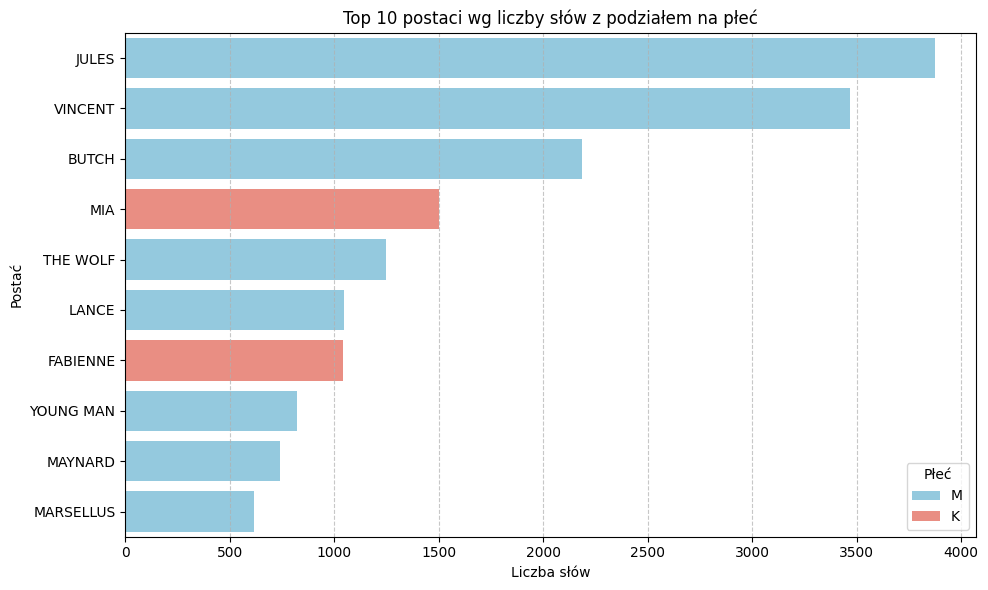

📊 Procent słów wypowiedzianych przez postacie kobiece: 17.95%


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge ranking with gender dictionary
postacie = ranking.copy()
postacie['plec'] = postacie['postac'].map(plec)

# 2. Calculate percentages
total_words = postacie['liczba_slow'].sum()
women_words = postacie[postacie['plec'] == 'K']['liczba_slow'].sum()
perc_women = (women_words / total_words) * 100

# 3. Prepare data for the plot (Top 10)
top_10 = postacie.head(10)

# 4. Visualization
plt.figure(figsize=(10, 6))
colors = {'M': 'skyblue', 'K': 'salmon', '?': 'lightgrey'}

sns.barplot(
    data=top_10,
    x='liczba_slow',
    y='postac',
    hue='plec',
    palette=colors,
    dodge=False
)

plt.title('Top 10 postaci wg liczby słów z podziałem na płeć')
plt.xlabel('Liczba słów')
plt.ylabel('Postać')
plt.legend(title='Płeć', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Show percentage
print(f"📊 Procent słów wypowiedzianych przez postacie kobiece: {perc_women:.2f}%")

#### Po uruchomieniu powinieneś zobaczyć

- Poziomy wykres postaci kolorowanych płcią, z tytułem i legendą.
- Pod wykresem procent słów wypowiedzianych przez postacie kobiece.

#### Pytanie interpretacyjne

Jaki procent dialogu należy do kobiet? Czy ten film „przeszedłby" intuicyjny test reprezentacji? Pamiętaj o granicy metody: udział w mowie ≠ znaczenie postaci — milczenie też bywa znaczące.

---
## Etap 6/6 — Eksport danych

Zapisujemy dwa pliki wejściowe do następnego notatnika.

In [ ]:
# === ETAP 6/6 · EKSPORT DANYCH ===
assert 'postacie' in dir() or ('ranking' in dir() and 'plec' in dir()), \
    "⛔ Najpierw uruchom Etapy 3, 4 i 5 — brakuje danych do eksportu."
print("📍 Etap 6/6 · Eksport. Zapisujemy `dialogi.csv` i `postacie.csv`.")

### Krok 6A. Zapis plików `dialogi.csv` i `postacie.csv`

#### Cel i sens analityczny

Rozdzielamy dane na dwa poziomy: kwestie (`dialogi.csv`) i podsumowanie postaci z płcią (`postacie.csv`). Ten podział wystarczy do analizy emocji w kolejnym module.

#### Prompt dla modelu

```text
Kontekst:
Masz tabelę kwestii w `dialogi`, tabelę `postacie` (ranking + płeć z Etapu 5) i słownik `plec`.

Wejście:
Tabela `dialogi` i tabela `postacie`.

Zadanie:
Zapisz dwa pliki CSV. Plik `dialogi.csv`: jeden wiersz na kwestię, kolumny: numer sceny, postać, treść kwestii, liczba słów. Plik `postacie.csv`: jeden wiersz na postać, kolumny: postać, płeć, liczba słów, liczba kwestii, liczba scen. Kodowanie UTF-8. Zachowaj tabelę postaci jako zmienną o nazwie `postacie`.

Pokaż wynik:
- komunikat o zapisaniu obu plików z liczbą wierszy,
- wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki niepuste. Liczba wierszy w `dialogi.csv` = liczba kwestii; w `postacie.csv` = liczba postaci.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i dlaczego.

Nie rób już nic więcej.
```

In [33]:
import pandas as pd
from google.colab import files

# 1. Prepare postacie dataframe (merging ranking and gender if not done fully before)
postacie = ranking.copy()
postacie['plec'] = postacie['postac'].map(plec)

# 2. Save to CSV
dialogi.to_csv('dialogi.csv', index=False, encoding='utf-8')
postacie.to_csv('postacie.csv', index=False, encoding='utf-8')

# 3. Output results
print(f"✅ Plik dialogi.csv zapisany ({len(dialogi)} wierszy).")
print(f"✅ Plik postacie.csv zapisany ({len(postacie)} wierszy).")
print("\n💡 Aby pobrać pliki na dysk, otwórz ikonę folderu w lewym panelu Colab, kliknij prawym przyciskiem myszy na plik i wybierz 'Pobierz' (Download).")

✅ Plik dialogi.csv zapisany (1193 wierszy).
✅ Plik postacie.csv zapisany (55 wierszy).

💡 Aby pobrać pliki na dysk, otwórz ikonę folderu w lewym panelu Colab, kliknij prawym przyciskiem myszy na plik i wybierz 'Pobierz' (Download).


#### Po uruchomieniu powinieneś zobaczyć

- Potwierdzenie zapisania `dialogi.csv` i `postacie.csv` z liczbą wierszy.
- Wskazówkę, jak pobrać pliki z Google Colab.

---
## Co dalej?

- Masz teraz `dialogi.csv` (pojedyncze wypowiedzi) i `postacie.csv` (postacie z płcią i ilością mowy).
- W **NB2** ocenisz emocje każdej kwestii i narysujesz łuk emocjonalny filmu oraz rozkład emocji wg płci.
- W **NB3** połączysz wszystko z siecią w jedną prezentację.
- Jeśli któryś krok zadziałał źle, poproś model o poprawienie tylko tego jednego fragmentu.